# 공통 파이프라인

In [1]:
# 1. 필요한 모듈 임포트
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import time

In [2]:
# 2 - 1. 데이터 로드
# v1_0.csv - 원본 데이터에 인코딩만
# v2_0.csv - v1_0.csv에 파생 변수 6개 추가
# v3_0.csv - 핵심 변수 12개 + 타겟 변수 (Churned) 1개
df1=pd.read_csv('Downloads/v1_0.csv')


In [3]:
df1.drop(columns='City', inplace=True)

In [4]:
# 2 - 2. 로드된 데이터1 확인
print("=" * 60)
print("데이터 확인")
print("=" * 60)
print(f"Shape1: {df1.shape}")
print(f"이탈률1: {df1['Churned'].mean()*100:.1f}%")

# 결측치 확인
missing = df1.isnull().sum().sum()
if missing > 0:
    print(f"\n⚠️ 결측치 {missing}개 발견")
else:
    print("\n✅ 결측치 없음")

데이터 확인
Shape1: (44348, 33)
이탈률1: 29.1%

✅ 결측치 없음


In [5]:
# 3. Feature 변수와 Target 변수 분리1
X1 = df1.drop('Churned', axis=1)
y1 = df1['Churned']

print(f"Feature Shape1: {X1.shape}")
print(f"Target Shape1: {y1.shape}")
print(f"\nFeature 컬럼1:")
print(X1.columns.tolist())

Feature Shape1: (44348, 32)
Target Shape1: (44348,)

Feature 컬럼1:
['Age', 'Membership_Years', 'Login_Frequency', 'Session_Duration_Avg', 'Pages_Per_Session', 'Cart_Abandonment_Rate', 'Wishlist_Items', 'Total_Purchases', 'Average_Order_Value', 'Days_Since_Last_Purchase', 'Discount_Usage_Rate', 'Returns_Rate', 'Email_Open_Rate', 'Customer_Service_Calls', 'Product_Reviews_Written', 'Social_Media_Engagement_Score', 'Mobile_App_Usage', 'Payment_Method_Diversity', 'Lifetime_Value', 'Gender_Male', 'Gender_Other', 'Country_Canada', 'Country_France', 'Country_Germany', 'Country_India', 'Country_Japan', 'Country_UK', 'Country_USA', 'Quarter_Q2', 'Quarter_Q3', 'Quarter_Q4', 'Credit_Group_encoded']


In [6]:
# 4. Train/Test 분리
# 🚨 중요: 절대 바꾸지 마세요! (팀원 모두 동일 설정)
RANDOM_STATE = 42
TEST_SIZE = 0.2

X_train, X_test, y_train, y_test = train_test_split(
    X1, y1,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y1 # <- ← 이탈률 비율 유지하면서 분리 되도록 (Train/Test 모두 29.1% 이탈률 가지도록)
)

print("\n" + "=" * 60)
print("Train/Test 분리 완료")
print("=" * 60)
print(f"Train: {X_train.shape[0]:,}개 ({(1-TEST_SIZE)*100:.0f}%)")
print(f"Test:  {X_test.shape[0]:,}개 ({TEST_SIZE*100:.0f}%)")

# 분리 후 이탈률 확인
print(f"\nTrain 이탈률: {y_train.mean()*100:.1f}%")
print(f"Test 이탈률:  {y_test.mean()*100:.1f}%")


Train/Test 분리 완료
Train: 35,478개 (80%)
Test:  8,870개 (20%)

Train 이탈률: 29.1%
Test 이탈률:  29.1%


In [7]:
# ============================================================
# 공통 평가 함수 - evaluate_model
# ============================================================

def evaluate_model(model1, X_test, y_test, model_name="xgboost1"):
    """
    출력 예시
    
    Parameters:
    -----------
    model: 학습된 모델
    X_test: 테스트 Feature
    y_test: 테스트 Target
    model_name: 모델 이름
    
    Returns:
    --------
    dict: 평가 결과 (f1, accuracy 등)
    """
    
    print("\n" + "=" * 60)
    print(f"{model_name} 평가")
    print("=" * 60)
    
    # 예측
    y_pred = model1.predict(X_test)
    
    # 확률 (있으면)
    if hasattr(model1, 'predict_proba'):
        y_proba = model1.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_proba)
    else:
        y_proba = None
        auc = None
    
    # 평가 지표
    from sklearn.metrics import accuracy_score, precision_score, recall_score
    
    f1 = f1_score(y_test, y_pred)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    
    # 출력
    print(f"\nF1-Score:  {f1:.4f}")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    if auc:
        print(f"AUC-ROC:   {auc:.4f}")
    
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    print("Confusion Matrix:")
    cm = confusion_matrix(y_test, y_pred)
    print(cm)


    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted Label1')
    plt.ylabel('True Label1')
    plt.show()
    
    # 결과 딕셔너리
    results = {
        'model_name': model_name,
        'f1_score': f1,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'auc': auc,
        'confusion_matrix': cm
    }
    
    return results

In [8]:
# ============================================================
# 공통 평가 함수 - show_feature_importance
# ============================================================
def show_feature_importance(model1, feature_names, top_n=10, model_name="xgboost1"):
    """
    출력 예시
    
    Feature Importance 출력 함수
    
    Parameters:
    -----------
    model: 학습된 모델
    feature_names: Feature 이름 리스트
    top_n: 상위 몇 개 보여줄지
    model_name: 모델 이름
    """
    
    if not hasattr(model1, 'feature_importances_'):
        print(f"⚠️ {model_name}은 Feature Importance 없음")
        return None
    
    # DataFrame으로 정리
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': model1.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    print("\n" + "=" * 60)
    print(f"{model_name} - Feature Importance Top {top_n}")
    print("=" * 60)
    
    for i, row in importance_df.head(top_n).iterrows():
        print(f"{row.name+1:2d}. {row['Feature']:30s}: {row['Importance']:.4f}")
    
# 시각화
    plt.figure(figsize=(10, 6))
    top_features = importance_df.head(top_n)
    plt.barh(range(len(top_features)), top_features['Importance'].values,
            color='skyblue', edgecolor='black')
    plt.yticks(range(len(top_features)), top_features['Feature'])
    plt.xlabel('Importance')
    plt.title(f'{model_name} - Feature Importance Top {top_n}')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    return importance_df

In [9]:
# 5. 모델 정의
# TODO : xgboost - https://xgboost.readthedocs.io/en/stable/parameter.html#

# ex
# import 모델
# 모델 정의
# model = 모델(하이퍼파라미터)
# MODEL_NAME = "자기 모델 이름" <- 이건 꼭 써주세요. 모델 평가 함수에서 사용해서 그렇습니다.

import xgboost as xgb

model1 = xgb.XGBClassifier(n_estimators=100, max_depth=10, random_state=42) #learning_rate=0.3??
MODEL_NAME = "xgboost1"


In [10]:
# 6. 모델 학습
print(f"\n{MODEL_NAME} 학습 시작...")
start_time = time.time()

model1.fit(X_train, y_train)

train_time = time.time() - start_time
print(f"✅ 학습 완료! (소요시간: {train_time:.1f}초)")


xgboost1 학습 시작...
✅ 학습 완료! (소요시간: 0.5초)



xgboost1 평가

F1-Score:  0.8415
Accuracy:  0.9145
Precision: 0.9129
Recall:    0.7804
AUC-ROC:   0.9139

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.97      0.94      6292
           1       0.91      0.78      0.84      2578

    accuracy                           0.91      8870
   macro avg       0.91      0.87      0.89      8870
weighted avg       0.91      0.91      0.91      8870

Confusion Matrix:
[[6100  192]
 [ 566 2012]]


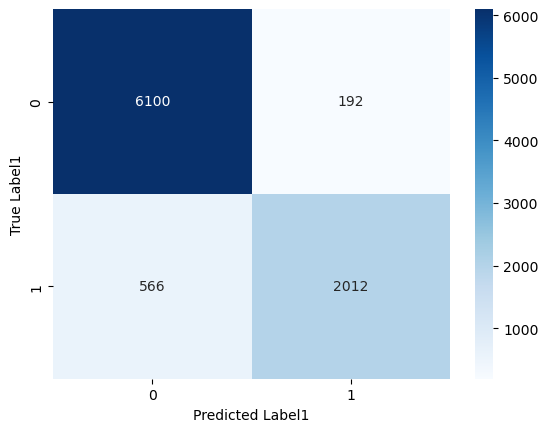

{'model_name': 'xgboost1',
 'f1_score': 0.8414889167712254,
 'accuracy': 0.914543404735062,
 'precision': 0.9128856624319419,
 'recall': 0.7804499612102405,
 'auc': 0.9138853467922867,
 'confusion_matrix': array([[6100,  192],
        [ 566, 2012]])}

In [11]:
# 7. 모델 평가 (모델 평가 함수 evaluate_model 사용)
results1 = evaluate_model(model1, X_test, y_test, MODEL_NAME)
results1


xgboost1 - Feature Importance Top 10
19. Lifetime_Value                : 0.1381
14. Customer_Service_Calls        : 0.1228
 6. Cart_Abandonment_Rate         : 0.0809
11. Discount_Usage_Rate           : 0.0646
 8. Total_Purchases               : 0.0475
 1. Age                           : 0.0460
10. Days_Since_Last_Purchase      : 0.0410
13. Email_Open_Rate               : 0.0378
 7. Wishlist_Items                : 0.0244
15. Product_Reviews_Written       : 0.0239


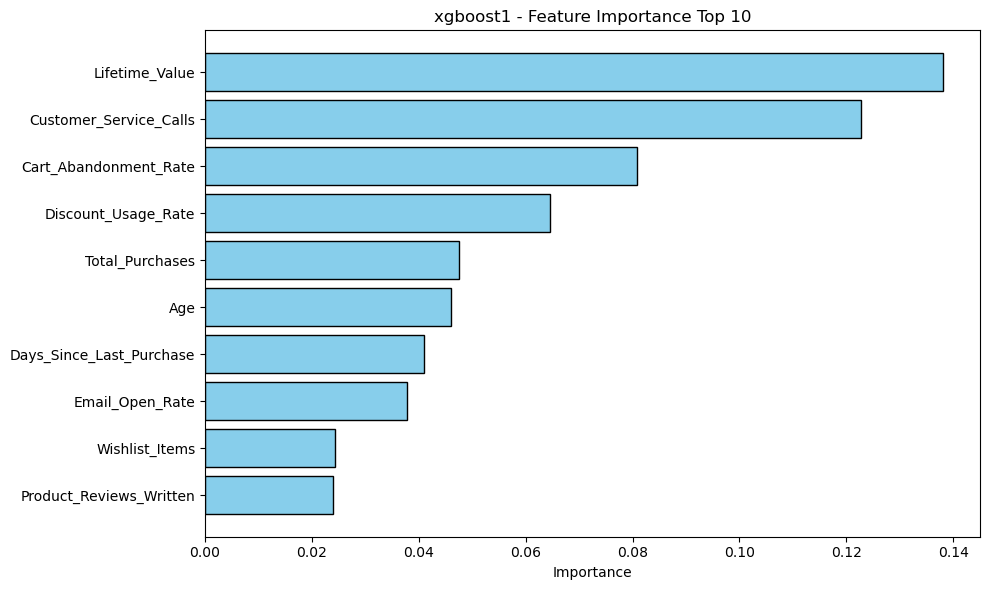

,Feature,Importance
18,Lifetime_Value,0.138099
13,Customer_Service_Calls,0.122779
5,Cart_Abandonment_Rate,0.080851
10,Discount_Usage_Rate,0.064587
7,Total_Purchases,0.047451
0,Age,0.046048
9,Days_Since_Last_Purchase,0.040997
12,Email_Open_Rate,0.037837
6,Wishlist_Items,0.024393
14,Product_Reviews_Written,0.023910


In [12]:
# 8. Feature Importance 확인 (Optional)
importance1 = show_feature_importance(model1, X_train.columns, top_n=10, model_name=MODEL_NAME)
importance1

In [13]:
# 9. 결과 요약
print("\n" + "=" * 60)
print("최종 결과 요약")
print("=" * 60)
print(f"모델: {MODEL_NAME}")
print(f"F1-Score: {results1['f1_score']:.4f}")
print(f"Accuracy: {results1['accuracy']:.4f}")
print(f"학습 시간: {train_time:.1f}초")

# 팀 공유용 한 줄 요약
print(f"\n📊 공유용: {MODEL_NAME} | F1={results1['f1_score']:.4f} | Acc={results1['accuracy']:.4f}")


최종 결과 요약
모델: xgboost1
F1-Score: 0.8415
Accuracy: 0.9145
학습 시간: 0.5초

📊 공유용: xgboost1 | F1=0.8415 | Acc=0.9145


In [14]:
# ============================================================
# 🔧 트러블슈팅 가이드 Claude가 써서 팩트 체크 필요하긴 합니다.
# ============================================================
"""
자주 발생하는 문제와 해결법:

1. "Churned 컬럼이 없습니다"
   → 데이터 파일 확인! v3_0.csv가 맞나요?
   → df.columns 출력해서 확인

2. "결측치 에러"
   → X = X.fillna(0) 추가
   
3. "Logistic Regression이 너무 오래 걸림"
   → max_iter=1000 추가
   → 또는 스케일링 필수!
   
4. "Feature Importance가 안 나옴"
   → Logistic Regression은 feature_importances_ 없음
   → coefficients 사용 (별도 코드 필요)
   
5. "학습이 너무 느림"
   → n_jobs=-1 추가 (모든 CPU 사용)
   → n_estimators 줄이기
"""

# >>>>> 변수명 일치하는 지 꼭 확인해주세요!! <<<<<

'\n자주 발생하는 문제와 해결법:\n\n1. "Churned 컬럼이 없습니다"\n   → 데이터 파일 확인! v3_0.csv가 맞나요?\n   → df.columns 출력해서 확인\n\n2. "결측치 에러"\n   → X = X.fillna(0) 추가\n\n3. "Logistic Regression이 너무 오래 걸림"\n   → max_iter=1000 추가\n   → 또는 스케일링 필수!\n\n4. "Feature Importance가 안 나옴"\n   → Logistic Regression은 feature_importances_ 없음\n   → coefficients 사용 (별도 코드 필요)\n\n5. "학습이 너무 느림"\n   → n_jobs=-1 추가 (모든 CPU 사용)\n   → n_estimators 줄이기\n'